In [138]:
import matplotlib.pyplot as plt
import pandas as pd
import r3b
import ROOT
import seaborn as sns

canvas = ROOT.TCanvas("canvas", "canvas", 600, 600)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


In [3]:
!mpirun -n 30 neuland sim -c "neuland_sim_config.json" > "sim.log" 2> "sim_error.log"

In [ ]:
!neuland ana -c "ana_config.json" > "ana.log" 2> "ana_error.log"

In [2]:
output_dir = "/lustre/r3b/ywang/analysis/jupyter/neuland_doc"

In [96]:
!neuland ana -c "ana_config.json" \
'general.output.data="window.output.root"' \
'general.output.par="window.par.root"' \
'tasks.NeulandDigitizer.pileup-strategy="time_window"' \
-v info > "ana.log" 2> "ana_error.log"

In [97]:
!neuland ana -c "ana_config.json" \
'general.output.data="distance.output.root"' \
'general.output.par="distance.par.root"' \
'tasks.NeulandDigitizer.pileup-strategy="distance"' \
-v info > "ana.log" 2> "ana_error.log"

In [186]:
def draw_size_plot_from(filename):
    digi_file = ROOT.TFile(f"{output_dir}/{filename}", "read")
    hist_dir = digi_file.Get("DataMonitor")

    hist_channel_signal = hist_dir.Get("channel_signal_size")
    hist_channel_hit = hist_dir.Get("channel_hit_size")
    hist_paddle_hit = hist_dir.Get("paddle_hit_size")
    hist_point_size = hist_dir.Get("filtered_point_size")

    channel_signal_df = r3b.th1d_to_df(hist_channel_signal)
    channel_signal_df["label"] = "channel signal"
    channel_signal_df["y"] = channel_signal_df["y"] / 2
    channel_hit_df = r3b.th1d_to_df(hist_channel_hit)
    channel_hit_df["y"] = channel_hit_df["y"] / 2
    channel_hit_df["label"] = "channel hit"
    paddle_hit_df = r3b.th1d_to_df(hist_paddle_hit)
    paddle_hit_df["label"] = "paddle hit"
    point_size_df = r3b.th1d_to_df(hist_point_size)
    point_size_df["label"] = "paddle signal"

    dataframe = pd.concat(
        [point_size_df, channel_signal_df, channel_hit_df, paddle_hit_df]
    )

    dataframe = dataframe.astype({"x": "int32"})
    dataframe = dataframe[(dataframe["x"] > 0) & (dataframe["x"] <= 4)]
    return dataframe
    # ax = sns.barplot(data=dataframe, x="x", y="y", hue="label")
    
    # ax.tick_params(labelsize=9)
    # ax.set_yscale("log")
    # ax.set_xlabel("Multiplicity of signals/hits per event", fontsize = 12)
    # ax.set_ylabel("Entries", fontsize = 12)
    # ax.set_ylim(1.0, 1e7)
    # # ax.legend(fontsize=18)
    # sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5), title=None, frameon=False)
    # plt.setp(ax.get_legend().get_texts(), fontsize=12)
    # # plt.legend(fontsize = 20)
    # return ax

In [163]:
image_dir = "/u/yanwang/software/R3BRoot/neuland/docs/figs"

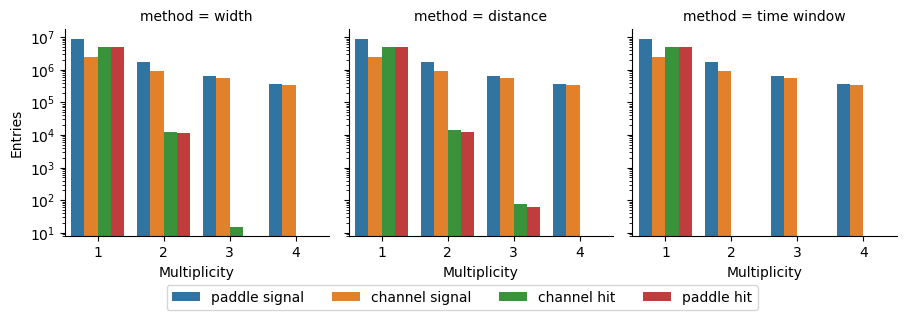

In [203]:
width_df = draw_size_plot_from("digi.output.root")
width_df["method"] = "width"
distance_df = draw_size_plot_from("distance.output.root")
distance_df["method"] = "distance"
window_df = draw_size_plot_from("window.output.root")
window_df["method"] = "time window"

all_df = pd.concat([width_df, distance_df, window_df])

value_order = all_df.x.unique()
g = sns.FacetGrid(all_df, col = "method")
g.map(sns.barplot, "x", "y", "label", hue_order=all_df.label.unique(), order = value_order, palette=sns.color_palette("tab10", n_colors = 4))
g.set(yscale = "log")
g.set(xlabel = "Multiplicity")
g.set(ylabel = "Entries")
# g.add_legend()
plt.legend(loc='upper right',ncol = 4, bbox_to_anchor=(0.5, -0.2))
plt.savefig(fname=f"{image_dir}/DigiWidthSize.png", bbox_inches="tight", dpi = 300)